### Source:
### https://github.com/dccuchile/CC5205

Esta implementación se basa en la teoria expuesta en las diapositivas (slides) de la clase 8 en el github, la idea es inicializar unos centroides aleatoriamente en el dataset, luego iterar un algoritmo que busca actualizar la pocisión de los centroides hasta que las variaciones en cada iteración sean minimas.

In [1]:
import numpy as np

def inicializar_centroides(X,k):
  return X[np.random.choice(X.shape[0],k,replace = False)]
def asignacion_cluster(X,centroides):
  distancias = np.zeros((X.shape[0], centroides.shape[0]))
  for i in range(centroides.shape[0]):
    distancias[:,i] = np.linalg.norm(X-centroides[i], axis=1)
  return np.argmin(distancias, axis=1)
def actualizar_centroides(X, labels, k):
  return np.array([X[labels==i].mean(axis=0) for i in range(k)])
def kmeans(X,k,max_iter=100, tol = 1e-4):
  centroides = inicializar_centroides(X,k)
  for i in range(max_iter):
    labels = asignacion_cluster(X,centroides)
    nuevos_centroides = actualizar_centroides(X,labels, k)
    if np.linalg.norm(nuevos_centroides - centroides)<tol:
      break
    centroides = nuevos_centroides
  return labels, centroides

In [2]:
#Implementar
# la primera parte de este bloque genera datos de clusters aleatorios y luego se implementan las funciones ya creadas
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
X,_=make_blobs(n_samples=300, centers = 5, cluster_std=0.60, random_state=0)
k = 5
labels, centroides = kmeans(X,k)
print(labels, centroides)

[3 4 1 3 2 2 0 1 0 4 3 3 1 4 4 1 1 0 3 2 0 2 1 3 2 1 2 0 4 2 0 3 1 3 3 4 0
 4 2 0 1 2 1 1 3 2 0 2 3 2 2 0 2 2 3 2 0 4 4 3 2 0 2 4 4 3 3 4 2 3 2 0 3 3
 3 3 3 4 1 0 4 4 1 3 3 4 0 0 0 2 4 0 0 3 2 4 1 4 4 1 3 2 0 4 0 1 2 0 1 2 1
 4 2 0 3 0 1 3 2 0 1 4 3 4 3 2 2 0 0 4 0 4 3 4 4 0 3 3 2 3 1 3 3 2 1 2 1 2
 4 1 3 4 3 1 3 1 2 4 3 4 2 1 4 1 1 2 1 3 4 1 0 0 1 3 0 1 4 4 2 0 1 2 0 1 2
 4 0 1 1 1 2 3 1 4 1 1 4 2 4 0 2 3 1 4 0 4 1 3 2 4 0 3 0 2 1 1 4 2 2 2 0 1
 3 0 0 2 2 4 1 4 4 1 1 3 1 2 2 1 3 0 4 3 4 0 1 0 3 3 4 3 4 4 4 0 2 0 0 2 4
 0 0 3 1 1 4 0 4 4 1 3 1 2 0 4 2 1 0 0 0 1 3 3 0 0 1 2 0 2 4 4 3 0 2 2 3 3
 3 2 0 1] [[ 2.00401597  0.84371973]
 [ 0.96475862  4.4261437 ]
 [-1.66877007  2.91652498]
 [ 9.12239104 -2.42822185]
 [-1.24268927  7.75317247]]


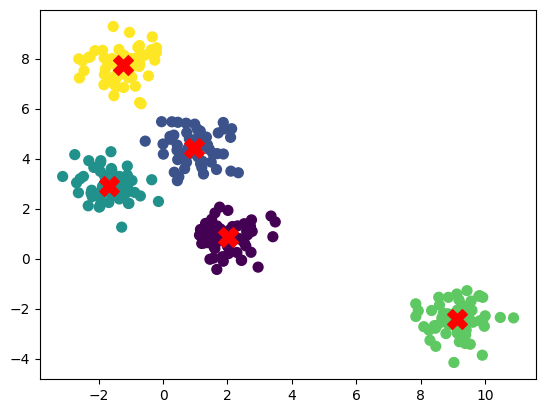

In [3]:
#Se imprimen los valores obtenidos con las funciones "a pie"
plt.scatter(X[:,0],X[:,1],c = labels, s=50, cmap="viridis")
plt.scatter(centroides[:,0],centroides[:,1], s=200, c= "red", marker = "X")
plt.show()

In [4]:
#Implementación con sklearn
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=65,n_init="auto").fit(X)
print(kmeans.labels_)
print(kmeans.cluster_centers_)
clusters2 = kmeans.cluster_centers_
labels2 = kmeans.labels_

[0 3 4 0 1 1 2 4 2 3 0 0 4 3 3 4 4 2 0 1 2 1 4 0 1 4 1 2 3 1 2 0 4 0 0 3 2
 3 1 2 4 1 4 4 0 1 2 1 0 1 1 2 1 1 0 1 2 3 3 0 1 2 1 3 3 0 0 3 1 0 1 2 0 0
 0 0 0 3 4 2 3 3 4 0 0 3 2 2 2 1 3 2 2 0 1 3 4 3 3 4 0 1 2 3 2 4 1 2 4 1 4
 3 1 2 0 2 4 0 1 2 4 3 0 3 0 1 1 2 2 3 2 3 0 3 3 2 0 0 1 0 4 0 0 1 4 1 4 1
 3 4 0 3 0 4 0 4 1 3 0 3 1 4 3 4 4 1 4 0 3 4 2 2 4 0 2 4 3 3 1 2 4 1 2 4 1
 3 2 4 4 4 1 0 4 3 4 4 3 1 3 2 1 0 4 3 2 3 4 0 1 3 2 0 2 1 4 4 3 1 1 1 2 4
 0 2 2 1 1 3 4 3 3 4 4 0 4 1 1 4 0 2 3 0 3 2 4 2 0 0 3 0 3 3 3 2 1 2 2 1 3
 2 2 0 4 4 3 2 3 3 4 0 4 1 2 3 1 4 2 2 2 4 0 0 2 2 4 1 2 1 3 3 0 2 1 1 0 0
 0 1 2 4]
[[ 9.12239104 -2.42822185]
 [-1.66877007  2.91652498]
 [ 2.00401597  0.84371973]
 [-1.24268927  7.75317247]
 [ 0.96475862  4.4261437 ]]


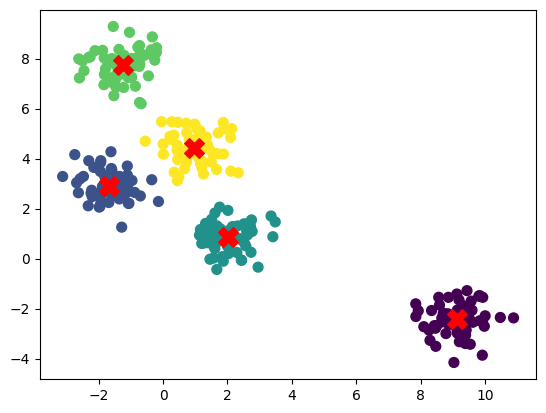

In [5]:
plt.scatter(X[:,0],X[:,1],c = labels2, s=50, cmap="viridis")
plt.scatter(clusters2[:,0],clusters2[:,1], s=200, c= "red", marker = "X")
plt.show()

### DBSCAN

In [6]:
from sklearn.neighbors import NearestNeighbors

In [7]:
def dbscan(X, eps, min_samples):
  labels3 = np.full(X.shape[0],-1)
  cluster_id=0
  nbrs=NearestNeighbors(radius = eps).fit(X)
  for i in range(X.shape[0]):
    if labels3[i] != -1:
      continue
    neighbors = nbrs.radius_neighbors([X[i]], return_distance = False)[0]
    if len(neighbors) < min_samples:
      labels3[i] = -1
    else:
      labels3[i] = cluster_id
      seeds = list(neighbors)
      while seeds:
        seed = seeds.pop()
        if labels3[seed] == -1:
          labels3[seed] = cluster_id
        else:
          continue
        labels3[seed] = cluster_id
        seed_neighbors = nbrs.radius_neighbors([X[seed]], return_distance = False)[0]
        if len(seed_neighbors) >= min_samples:
          seeds.extend(seed_neighbors)
        cluster_id += 1
    return labels3


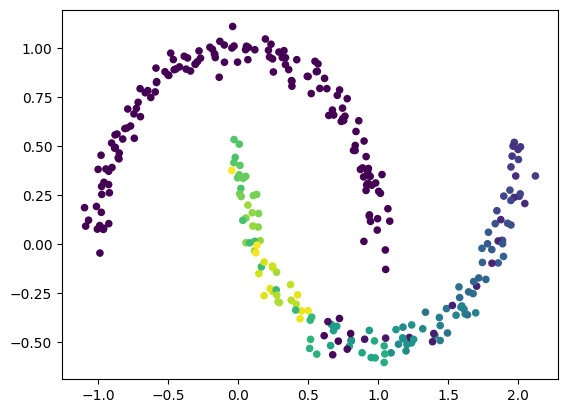

In [8]:
from sklearn.datasets import make_moons


X,_ = make_moons(n_samples= 300, noise =  0.05, random_state=0)
#X,_=make_blobs(n_samples=300, centers = 5, cluster_std=0.60, random_state=0)

labels = dbscan(X, eps=0.2, min_samples=5)

plt.scatter(X[:,0],X[:,1],c = labels,s=20,cmap="viridis")
plt.show()

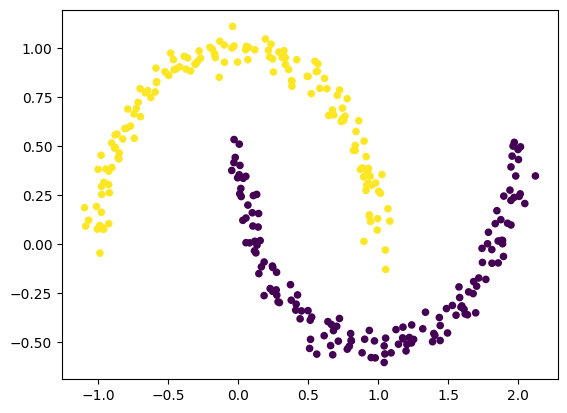

In [9]:
from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels4 = clustering.labels_
plt.scatter(X[:,0],X[:,1],c = labels4,s=20,cmap="viridis")
plt.show()